# TP — Classification de textes

---

Une banque reçoit des milliers de messages clients chaque jour :
- *"My card was declined at the ATM"*
- *"I want to transfer money to my friend"*
- *"Someone made a payment I don't recognize"*

**Objectif** : entraîner un modèle qui lit le message et le redirige automatiquement vers le bon service.

Nous allons classer chaque message dans l'une de ces 3 catégories :

| Classe | Description | Exemples |
|---|---|---|
| **Paiement** | Opérations de transfert, solde, recharge | virement, top-up, bénéficiaire |
| **Compte** | Gestion de la carte et du compte | carte expirée, PIN, mot de passe |
| **Litige** | Problèmes, fraudes, remboursements | carte bloquée, fraude, remboursement |

> **Prérequis** : TP Text Mining (prétraitement, vectorisation TF-IDF)

---
## Partie 1 — Théorie

---

### 1.1 — Qu'est-ce que la classification de texte ?

La **classification de texte** est une tâche supervisée : on dispose d'exemples étiquetés (texte -> classe) et on entraîne un modèle à apprendre cette correspondance pour prédire la classe de nouveaux textes.


![](assets/c01_img1.png)

Dans ce TP, nous allons tester et comparer **3 algorithmes** : Naïve Bayes, SVM, et Random Forest.

### 1.2 — Naïve Bayes (NB)

#### Principe

![image.png](assets/image.png)

Naïve Bayes est un classifieur probabiliste basé sur le **théorème de Bayes**

![image-2.png](assets/image-2.png)

$$P(classe\ |\ texte) = \frac{P(texte\ |\ classe) \times P(classe)}{P(texte)}$$

En pratique, pour chaque classe $c$ et chaque texte $d$ composé de mots $w_1, w_2, ..., w_n$ :

$$P(c\ |\ d) \propto P(c) \times \prod_{i=1}^{n} P(w_i\ |\ c)$$

L'hypothèse **naïve** : les mots sont **indépendants** entre eux. Faux en réalité, mais ça marche bien en pratique !

#### Comment ça s'entraîne ?

1. **Compter** : pour chaque classe, compter combien de fois chaque mot apparaît
2. **Estimer** : $P(mot\ |\ classe) = \dfrac{\text{nb occurrences du mot dans la classe}}{\text{nb total de mots dans la classe}}$
3. **Prédire** : pour un nouveau texte, calculer la probabilité de chaque classe et choisir la plus élevée

> Le **lissage de Laplace** (paramètre `alpha`) ajoute une petite valeur à chaque comptage pour éviter $P = 0$ quand un mot n'a jamais été vu dans une classe pendant l'entraînement.

#### Exemple

```
Texte : "card declined payment"

P(Litige  | texte) ∝ P(Litige)  × P(card|Litige)  × P(declined|Litige)  × P(payment|Litige)
P(Paiement| texte) ∝ P(Paiement)× P(card|Paiement)× P(declined|Paiement)× P(payment|Paiement)
P(Compte  | texte) ∝ P(Compte)  × P(card|Compte)  × P(declined|Compte)  × P(payment|Compte)

→ On choisit la classe avec la plus haute probabilité
```

#### Hyperparamètre clé

| Paramètre | Rôle | Valeurs typiques |
|---|---|---|
| `alpha` | Lissage de Laplace — évite P=0 pour les mots non vus | 0.1, 0.5, 1.0 (défaut) |

> Un `alpha` faible → le modèle fait plus confiance aux données. Un `alpha` élevé → plus de régularisation.

#### Avantages / Inconvénients

| Avantages | Inconvénients |
|---|---|
| Très rapide à entraîner et à prédire | Hypothèse d'indépendance irréaliste |
| Fonctionne bien avec peu de données | Moins performant si les mots sont très corrélés |
| Interprétable : on voit quels mots pèsent pour quelle classe | Sensible aux mots très fréquents (atténué par TF-IDF) |
| Bon point de départ (baseline solide) | |

### 1.3 — SVM (Support Vector Machine)

#### Principe

Le SVM cherche l'**hyperplan** qui sépare les classes avec la **marge maximale**. En classification de texte, chaque document est un vecteur dans un espace de haute dimension (une dimension par mot du vocabulaire).

![image.png](assets/c03_image.png)
#### Les vecteurs de support

Ce sont les **points les plus proches de l'hyperplan** — les exemples les plus difficiles à classer. Ce sont eux qui définissent la position de l'hyperplan. Si on retire tous les autres points d'entraînement, l'hyperplan ne bouge pas.

#### Astuce : le Kernel Trick

Quand les classes ne sont pas linéairement séparables, le SVM utilise une **fonction noyau (kernel)** pour projeter les données dans un espace de dimension supérieure où elles deviennent séparables.

![image-2.png](assets/c03_image-2.png)

#### Pourquoi `LinearSVC` pour le texte ?

Les vecteurs TF-IDF sont :
- **Haute dimension** (5 000+ features avec nos paramètres)
- **Creux (sparse)** : la plupart des mots sont absents d'un message donné

Dans cet espace, les classes sont souvent **linéairement séparables** — un kernel linéaire suffit. `LinearSVC` est une implémentation optimisée pour ce cas, bien plus rapide que `SVC(kernel='linear')` sur de grands vocabulaires.

#### Hyperparamètres clés

| Paramètre | Rôle | Valeurs typiques |
|---|---|---|
| `C` | Pénalité pour les erreurs de classification — C élevé = moins d'erreurs tolérées = risque de surapprentissage | 0.1, 1, 10, 100 |
| `kernel` | Fonction de transformation de l'espace | `linear`, `rbf`, `poly` |
| `gamma` | Portée d'influence de chaque exemple (kernel RBF) | `scale`, `auto`, 0.1, 0.01 |

> Pour le texte, `kernel='linear'` (ou `LinearSVC`) est presque toujours le bon choix.

#### Avantages / Inconvénients

| Avantages | Inconvénients |
|---|---|
| Très performant sur les espaces haute dimension | Entraînement plus lent que Naïve Bayes |
| Robuste au surapprentissage grâce à la marge | Moins interprétable (pas de probabilités directes) |
| Particulièrement adapté aux données textuelles | Choix de C important — à régler par validation croisée |
| Peu sensible au nombre de features | | 

### 1.4 — Random Forest (RF)

#### Principe

Random Forest construit un **ensemble d'arbres de décision** entraînés sur des sous-échantillons aléatoires des données et des features. La prédiction finale est un **vote majoritaire** de tous les arbres.

![](assets/img_1.png)

#### Hyperparamètres clés

| Paramètre | Rôle | Valeurs typiques |
|---|---|---|
| `n_estimators` | Nombre d'arbres. Plus = meilleur mais plus lent | 100, 200, 500 |
| `max_depth` | Profondeur maximale de chaque arbre. Limiter évite le surapprentissage | None, 10, 20 |
| `max_features` | Nombre de features considérées à chaque split | `sqrt`, `log2`, 0.5 |

> Random Forest est robuste et nécessite peu de prétraitement, mais plus lent que NB et SVM sur du texte.

### 1.5 — Pipeline classique de classification de texte

```
Texte brut
    ↓
Prétraitement (nettoyage, tokenisation, stopwords)
    ↓
Vectorisation TF-IDF
(texte → vecteur numérique)
    ↓
Séparation Train / Test
    ↓
Entraînement du modèle
(Naïve Bayes / SVM / Random Forest)
    ↓
Évaluation
(Accuracy, Precision, Recall, F1)
    ↓
Comparaison des modèles
```

---
## Partie 2 — Pratique

---

### Étape 0 — Installation

In [45]:
!pip install nltk scikit-learn spacy --quiet
!python -m spacy download en_core_web_sm --quiet

In [46]:
import warnings
warnings.filterwarnings('ignore')

In [47]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
print('NLTK prêt.')

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Tout est pret.')

Tout est pret.


---
### Étape 1 — Chargement du dataset

**Banking77** contient 13 083 messages clients bancaires répartis en 77 intentions fines.
Nous allons les regrouper en **3 grandes classes** pour notre tâche.

In [50]:
import pandas as pd

df_train = pd.read_csv("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv")
df_test = pd.read_csv("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv")

print(df_train.shape, df_test.shape)
print(df_train.sample(20))

(10003, 2) (3080, 2)
                                                   text  \
1650                 Do you offer account's for minors?   
9668              How do you Top Up on the apple watch?   
4347    How many disposable cards am I allowed to have?   
8946  If I exchange currencies on a frequent basis c...   
84    If I ordered my new card last week, how much l...   
6383  Why do I have a transaction showing up more th...   
8189    I cannot get my disposable virtual card to work   
6587         I'd like to know where my funds come from.   
797   My account says I have money but I withdrew it...   
4397  Are there any restrictions for the disposable ...   
6004  Hi I am trying to transfer money to another co...   
4746  I see a charge for a direct debit that was not...   
5863                        I couldn't pay with my card   
6854      What happens if my card payment is cancelled?   
223   In the app, how can I make it show the new car...   
2243              How much is ok fo

In [51]:
category = df_train['category'].unique()
# Afficher toutes les intentions disponibles
print('Liste des 77 intentions :')
for i, name in enumerate(category):
    print(f'  {i:2d}. {name}')

Liste des 77 intentions :
   0. card_arrival
   1. card_linking
   2. exchange_rate
   3. card_payment_wrong_exchange_rate
   4. extra_charge_on_statement
   5. pending_cash_withdrawal
   6. fiat_currency_support
   7. card_delivery_estimate
   8. automatic_top_up
   9. card_not_working
  10. exchange_via_app
  11. lost_or_stolen_card
  12. age_limit
  13. pin_blocked
  14. contactless_not_working
  15. top_up_by_bank_transfer_charge
  16. pending_top_up
  17. cancel_transfer
  18. top_up_limits
  19. wrong_amount_of_cash_received
  20. card_payment_fee_charged
  21. transfer_not_received_by_recipient
  22. supported_cards_and_currencies
  23. getting_virtual_card
  24. card_acceptance
  25. top_up_reverted
  26. balance_not_updated_after_cheque_or_cash_deposit
  27. card_payment_not_recognised
  28. edit_personal_details
  29. why_verify_identity
  30. unable_to_verify_identity
  31. get_physical_card
  32. visa_or_mastercard
  33. topping_up_by_card
  34. disposable_card_limits
  35.

---
### Étape 2 — Regroupement en 3 classes

On regroupe les 77 intentions en 3 grandes familles métier.
C'est ce qu'on ferait en entreprise pour router les messages vers les bons services.

In [52]:
# Definition des 3 classes
PAIEMENT = [
    'transfer_internationally', 'transfer_not_received_by_recipient',
    'transfer_timing', 'transfer_fee_charged', 'transfer_into_account',
    'top_up_by_bank_transfer_charge', 'top_up_by_card_charge',
    'top_up_by_cash_or_cheque', 'top_up_failed', 'top_up_limits',
    'top_up_reverted', 'balance_not_updated_after_bank_transfer',
    'balance_not_updated_after_cheque_or_cash_deposit',
    'beneficiary_not_allowed', 'exchange_rate',
    'exchange_via_app', 'exchange_charge', 'fiat_currency_support',
    'pending_transfer', 'pending_top_up', 'receiving_money',
    'request_refund', 'supported_cards_and_currencies'
]

COMPTE = [
    'card_arrival', 'card_linking', 'card_about_to_expire',
    'card_acceptance', 'card_delivery_estimate',
    'pin_blocked', 'change_pin', 'activate_my_card',
    'age_limit', 'apple_pay_or_google_pay',
    'atm_support', 'automatic_top_up', 'contactless_not_working',
    'country_support', 'direct_debit_payment_not_recognised',
    'edit_personal_details', 'get_disposable_virtual_card',
    'get_physical_card', 'lost_or_stolen_card',
    'lost_or_stolen_phone', 'order_physical_card',
    'passcode_forgotten', 'verify_my_identity', 'verify_top_up',
    'virtual_card_not_working', 'visa_or_mastercard',
    'reverted_card_payment?', 'terminate_account',
    'spending_controls'
]

LITIGE = [
    'card_not_working', 'card_payment_fee_charged',
    'card_payment_not_recognised', 'card_payment_wrong_exchange_rate',
    'card_swallowed', 'cash_withdrawal_charge',
    'cash_withdrawal_not_recognised', 'compromised_card',
    'declined_card_payment', 'declined_cash_withdrawal',
    'declined_transfer', 'extra_charge_on_statement',
    'failed_transfer', 'fraud_dispute',
    'get_refund', 'pending_card_payment',
    'pending_cash_withdrawal', 'refund_not_showing_in_my_account',
    'wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal',
    'transaction_charged_twice', 'unable_to_verify_identity',
    'disposable_card_limits', 'banking_crisis'
]

print('Classes definies.')

Classes definies.


In [53]:
# Fonction de mapping intention -> classe
def mapper_classe(intent):
    if intent in PAIEMENT:
        return 'Paiement'
    elif intent in COMPTE:
        return 'Compte'
    elif intent in LITIGE:
        return 'Litige'
    else:
        return None  # intentions non assignees

df_train['classe'] = df_train['category'].apply(mapper_classe)
df_test['classe'] = df_test['category'].apply(mapper_classe)


In [54]:
print(df_train['classe'].unique())

['Compte' 'Paiement' 'Litige' None]


In [55]:
# Supprimer les messages non assignes
df_train = df_train[df_train['classe'].notna()].reset_index(drop=True)
df_test = df_test[df_test['classe'].notna()].reset_index(drop=True)

print(f'Messages conserves : {len(df_train)}')
print()
print('Distribution des classes :')
print(df_train['classe'].value_counts())

Messages conserves : 9120

Distribution des classes :
classe
Compte      3211
Paiement    2986
Litige      2923
Name: count, dtype: int64


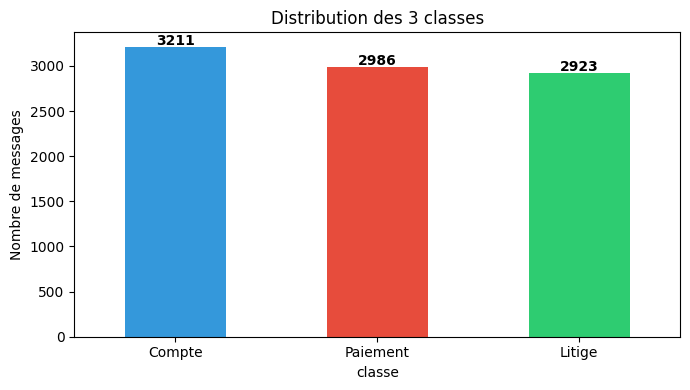

In [56]:
# Visualisation de la distribution
counts = df_train['classe'].value_counts()

plt.figure(figsize=(7, 4))
counts.plot(kind='bar', color=['#3498DB', '#E74C3C', '#2ECC71'])
plt.title('Distribution des 3 classes')
plt.ylabel('Nombre de messages')
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

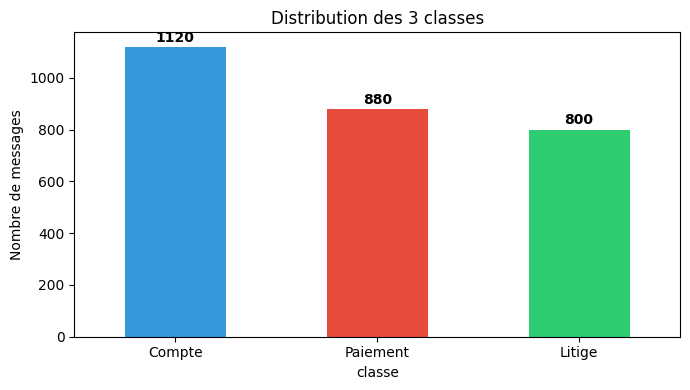

In [57]:
#visualisation de la distribution de test
# Visualisation de la distribution
counts = df_test['classe'].value_counts()

plt.figure(figsize=(7, 4))
counts.plot(kind='bar', color=['#3498DB', '#E74C3C', '#2ECC71'])
plt.title('Distribution des 3 classes')
plt.ylabel('Nombre de messages')
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Exemples par classe
print('=== Exemples de messages par classe ===\n')
for classe in ['Paiement', 'Compte', 'Litige']:
    exemples = df_train[df_train['classe'] == classe]['text'].sample(3, random_state=42).tolist()
    print(f'[{classe}]')
    for ex in exemples:
        print(f'  - {ex}')
    print()

=== Exemples de messages par classe ===

[Paiement]
  - Can you tell me your exchange rates?
  - I do not see the money I transferred into this account
  - Is it possible for me to top up with cash?

[Compte]
  - Can I open an account for my offspring?
  - Can you send me the actual card?
  - i live in portugal. do you operate here?

[Litige]
  - I don't know if I made this payment on my card.
  - Why has my payment not transferred?
  - I am not able to verify my id. Why?



---
### Étape 3 — Prétraitement

Chaque sous-étape est **appliquée au dataset complet** (train + test) pour observer les transformations sur les vraies données.

| Sous-étape | Outil | Colonne produite |
|---|---|---|
| Nettoyage regex | `re` | `text_clean` |
| Tokenisation | NLTK `word_tokenize` | `tokens` |
| Stopwords | NLTK + SpaCy (union) | `tokens` |
| Lemmatisation | SpaCy `en_core_web_sm` | `tokens_lemme` → `text_clean` |

#### 3.1 Nettoyage regex

On retire les chiffres, la ponctuation, et on met en minuscules.

In [ ]:
def nettoyer(texte):
    texte = re.sub(r'[^a-zA-Z\s]', ' ', texte)  # ponctuation et chiffres
    texte = re.sub(r'\s+',          ' ', texte)  # espaces multiples
    return texte.strip().lower()

In [ ]:
# Vérification sur 1 exemple avant d'appliquer
print('BRUT    :', df_train['text'].iloc[0])
print('NETTOYÉ :', nettoyer(df_train['text'].iloc[0]))

In [ ]:
# Application sur tout le dataset
df_train['text_clean'] = df_train['text'].apply(nettoyer)
df_test['text_clean']  = df_test['text'].apply(nettoyer)

df_train[['text', 'text_clean']].head(3)

#### 3.2 Tokenisation — NLTK

On découpe chaque message nettoyé en liste de mots.

In [ ]:
from nltk.tokenize import word_tokenize

# Vérification sur 1 exemple
ex = df_train['text_clean'].iloc[0]
print('Tokens :', word_tokenize(ex))

In [ ]:
# Application sur tout le dataset + filtre alpha (longueur > 2)
def tokeniser(texte):
    return [t for t in word_tokenize(texte) if t.isalpha() and len(t) > 2]

df_train['tokens'] = df_train['text_clean'].apply(tokeniser)
df_test['tokens']  = df_test['text_clean'].apply(tokeniser)

df_train[['text', 'tokens']].head(3)

#### 3.3 Stopwords

Deux bibliothèques pour l'anglais — on fait l'**union** pour une meilleure couverture.

In [ ]:
from nltk.corpus import stopwords

stop_nltk = set(stopwords.words('english'))
print(f'NLTK  : {len(stop_nltk)} stopwords — ex : {sorted(stop_nltk)[:8]}')

In [ ]:
from spacy.lang.en import stop_words

stop_spacy = stop_words.STOP_WORDS
print(f'SpaCy : {len(stop_spacy)} stopwords — ex : {sorted(stop_spacy)[:8]}')

In [ ]:
stop_en = stop_nltk | set(stop_spacy)
print(f'Union NLTK ∪ SpaCy : {len(stop_en)} stopwords')

In [ ]:
# Application sur tout le dataset
df_train['tokens'] = df_train['tokens'].apply(lambda t: [w for w in t if w not in stop_en])
df_test['tokens']  = df_test['tokens'].apply(lambda t: [w for w in t if w not in stop_en])

df_train[['text', 'tokens']].head(3)

#### 3.4 Lemmatisation — SpaCy `en_core_web_sm`

Réduit chaque token à sa **forme canonique** : `cards` → `card`, `declined` → `decline`, `payments` → `payment`.

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')
print('SpaCy prêt.')

In [ ]:
# Démonstration sur des termes bancaires
mots_demo = ['cards', 'declined', 'payments', 'transferring',
             'transactions', 'accounts', 'blocked', 'fraudulent']
doc_demo = nlp(' '.join(mots_demo))

print(f"{'Mot original':<20} {'Lemme':<20} {'POS'}")
print('-' * 55)
for tok in doc_demo:
    print(f"{tok.text:<20} {tok.lemma_:<20} {tok.pos_}")

In [ ]:
# Application sur tout le dataset
def lemmatiser(tokens):
    doc = nlp(' '.join(tokens))
    return [tok.lemma_.lower() for tok in doc
            if not tok.is_stop and len(tok.lemma_) > 2]

print('Lemmatisation en cours (~2 min)...')
df_train['tokens_lemme'] = df_train['tokens'].apply(lemmatiser)
df_test['tokens_lemme']  = df_test['tokens'].apply(lemmatiser)
print('Terminé.')

In [ ]:
df_train[['text', 'tokens', 'tokens_lemme']].head(3)

#### 3.5 Résumé — du texte brut aux lemmes

Observation des 4 colonnes côte à côte sur 5 exemples aléatoires.

In [ ]:
df_train[['text', 'text_clean', 'tokens', 'tokens_lemme']].sample(5, random_state=42)

#### 3.6 Finalisation — `text_clean` prêt pour la vectorisation

On joint les lemmes en une chaîne de caractères : c'est l'entrée du vectoriseur TF-IDF.

In [ ]:
df_train['text_clean'] = df_train['tokens_lemme'].apply(' '.join)
df_test['text_clean']  = df_test['tokens_lemme'].apply(' '.join)

print('BRUT   :', df_train['text'].iloc[0])
print()
print('PROPRE :', df_train['text_clean'].iloc[0])

---
### Étape 4 — Vectorisation TF-IDF

On transforme chaque message en vecteur numérique.

- `max_features` : 5 000 mots les plus informatifs
- `ngram_range=(1,2)` : mots seuls **et** bigrammes (`card declined`, `transfer failed`)

> **Important** : Banking77 fournit déjà un train set et un test set séparés. On les utilise directement — pas besoin de `train_test_split`.

In [ ]:
# Utilisation des splits Banking77 officiels
X_train = df_train['text_clean']
y_train = df_train['classe']

X_test  = df_test['text_clean']
y_test  = df_test['classe']

print(f'Train : {len(X_train)} messages | Test : {len(X_test)} messages')

In [ ]:
# Vectorisation TF-IDF
# IMPORTANT : fit sur train seulement, transform sur train ET test
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=list(stop_en)
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'Dimension des vecteurs : {X_train_vec.shape}')
print(f'({X_train_vec.shape[0]} messages, {X_train_vec.shape[1]} features TF-IDF)')

---
### Étape 5 — Modèle 1 : Naïve Bayes

On commence par Naïve Bayes, le plus simple et le plus rapide.

In [ ]:
# Entrainement
nb = MultinomialNB(alpha=1.0)  # alpha=1.0 : lissage de Laplace standard
nb.fit(X_train_vec, y_train)

In [ ]:
# Prediction
y_pred_nb = nb.predict(X_test_vec)

In [ ]:
# Evaluation
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy Naive Bayes : {acc_nb*100:.2f}%')
print()
print(classification_report(y_test, y_pred_nb))

In [ ]:
# Matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Paiement', 'Compte', 'Litige'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paiement', 'Compte', 'Litige'],
            yticklabels=['Paiement', 'Compte', 'Litige'])
plt.title('Matrice de confusion — Naive Bayes')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.tight_layout()
plt.show()

> **Comment lire la matrice de confusion ?**
> - La **diagonale** = prédictions correctes
> - Les cases hors diagonale = erreurs
> - Exemple : ligne Litige / colonne Paiement = messages Litige classés à tort en Paiement

---
### Étape 6 — Modèle 2 : SVM

On utilise `LinearSVC` — version linéaire du SVM, très efficace sur le texte.

In [ ]:
# Entrainement
# C=1.0 : penalite standard (bon point de depart)
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_train_vec, y_train)

In [ ]:
# Prediction et evaluation
y_pred_svm = svm.predict(X_test_vec)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy SVM : {acc_svm*100:.2f}%')
print()
print(classification_report(y_test, y_pred_svm))

In [ ]:
# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['Paiement', 'Compte', 'Litige'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Paiement', 'Compte', 'Litige'],
            yticklabels=['Paiement', 'Compte', 'Litige'])
plt.title('Matrice de confusion — SVM')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.tight_layout()
plt.show()

---
### Étape 7 — Modèle 3 : Random Forest

In [ ]:
# Entrainement
# n_estimators=200 : 200 arbres (bon compromis vitesse/performance)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_vec, y_train)

In [ ]:
# Prediction et evaluation
y_pred_rf = rf.predict(X_test_vec)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy Random Forest : {acc_rf*100:.2f}%')
print()
print(classification_report(y_test, y_pred_rf))

In [ ]:
# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Paiement', 'Compte', 'Litige'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Paiement', 'Compte', 'Litige'],
            yticklabels=['Paiement', 'Compte', 'Litige'])
plt.title('Matrice de confusion — Random Forest')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.tight_layout()
plt.show()

---
### Étape 8 — Comparaison des 3 modèles

In [ ]:
# Tableau recapitulatif
from sklearn.metrics import f1_score

resultats = pd.DataFrame({
    'Modele'   : ['Naive Bayes', 'SVM', 'Random Forest'],
    'Accuracy' : [acc_nb, acc_svm, acc_rf],
    'F1 macro' : [
        f1_score(y_test, y_pred_nb,  average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_rf,  average='macro')
    ]
})

resultats['Accuracy'] = (resultats['Accuracy'] * 100).round(2)
resultats['F1 macro'] = (resultats['F1 macro'] * 100).round(2)
print(resultats.to_string(index=False))

In [ ]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modeles = ['Naive Bayes', 'SVM', 'Random Forest']
couleurs = ['#3498DB', '#E74C3C', '#2ECC71']

# Accuracy
axes[0].bar(modeles, resultats['Accuracy'], color=couleurs)
axes[0].set_title('Accuracy par modele (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(resultats['Accuracy']):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# F1 Score
axes[1].bar(modeles, resultats['F1 macro'], color=couleurs)
axes[1].set_title('F1 Score macro par modele (%)')
axes[1].set_ylim([0, 100])
for i, v in enumerate(resultats['F1 macro']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Matrices de confusion cote a cote
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
classes = ['Paiement', 'Compte', 'Litige']

for ax, cm, titre, cmap in zip(
    axes,
    [cm_nb, cm_svm, cm_rf],
    ['Naive Bayes', 'SVM', 'Random Forest'],
    ['Blues', 'Oranges', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f'Matrice de confusion\n{titre}')
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')

plt.tight_layout()
plt.show()

---
### Étape 9 — Tester sur de nouveaux messages

On teste le meilleur modèle sur des messages inventés pour vérifier son comportement.

In [ ]:
# Choisir le meilleur modele
meilleur_modele = max(
    [('Naive Bayes', nb, acc_nb),
     ('SVM', svm, acc_svm),
     ('Random Forest', rf, acc_rf)],
    key=lambda x: x[2]
)
print(f'Meilleur modele : {meilleur_modele[0]} ({meilleur_modele[2]*100:.2f}%)')
modele_final = meilleur_modele[1]

In [ ]:
# Nouveaux messages a tester
nouveaux_messages = [
    "I tried to pay at the supermarket but my card was declined",
    "How do I change my PIN number?",
    "I want to send money to my friend in France",
    "Someone made a payment I don't recognize on my account",
    "My card hasn't arrived yet, it's been 10 days",
    "I need a refund for a wrong transaction"
]

In [ ]:
# Prétraitement + vectorisation avec la même pipeline que l'entraînement
messages_clean = [pretraiter(m) for m in nouveaux_messages]
messages_vec   = tfidf.transform(messages_clean)

predictions = modele_final.predict(messages_vec)

print('=== Prédictions sur nouveaux messages ===\n')
for msg, pred in zip(nouveaux_messages, predictions):
    print(f'Message : {msg}')
    print(f'Classe  : {pred}')
    print()

---
### Bilan

| Modèle | Points forts | Points faibles |
|---|---|---|
| **Naïve Bayes** | Très rapide, peu de données suffisent | Hypothèse d'indépendance irréaliste |
| **SVM** | Excellent sur le texte, robuste | Moins interprétable, lent sur grands corpus |
| **Random Forest** | Robuste, pas de normalisation nécessaire | Lent sur données de haute dimension (texte) |

**Points clés à retenir :**
- Le **SVM linéaire** est généralement le meilleur choix pour la classification de texte.
- **Naïve Bayes** est un excellent baseline : rapide et souvent surprenant.
- **Random Forest** est moins adapté au texte (haute dimension) mais reste compétitif.
- La **matrice de confusion** révèle quelles classes se confondent — plus utile que l'accuracy seule.
- Le paramètre `C` du SVM et `alpha` de Naïve Bayes sont les plus importants à régler.